<a href="https://colab.research.google.com/github/DAnirudhM/UT-Austin-AI-Course/blob/main/Project_2_AI_powered_EHR_Assistant_Full_code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A healthcare provider network offers a patient portal for accessing EHR data (labs, medications, visit summaries, imaging impressions, discharge instructions). Patients frequently misunderstand clinical terminology and next steps, driving high volumes of portal messages and call-center contacts, reduced adherence, and dissatisfaction. Patients also search online, encountering misinformation that may conflict with their records.

However, a patient-facing AI layer introduces non-trivial risks:
- misinterpretation of outputs as medical advice
- unsafe self-management behaviors
- inequities from varying health literacy, and
- PHI exposure through new interfaces and integrations.

The organization therefore needs a patient education and navigation assistant that is clinically safe-by-design, privacy-preserving, and auditable, with clear boundaries and escalation to clinicians.

## Objective

The objective is to build a POC in the form of a guardrailed, patient-facing AI education and navigation assistant powered by a single-agent system within the patient portal that:
- explains selected parts of the patient's record in plain language,
- answers general medical questions using vetted sources with citations, and
- enforces safety constraints (no diagnosis, no medication changes, no urgent-care triage beyond 'seek immediate care')

The end goal is to scale and expose this POC as an assistant to the patients to reduce avoidable support contacts and improve comprehension/adherence.

## Data Dictionary

**1) SQLite database (clinical operational data)**  
Use SQLite to represent a portal/EHR backend. Keep the dataset small (e.g., 5-20 patients, 50-200 lab rows, 20-50 medications, 10-30 encounters) while maintaining realistic clinical fields.

**Table: patients**  
**Purpose:** patient identity and personalization (minimize PHI).  
**Key attributes:**
- patient_id (PK)
- first_name
- last_name (optional)
- dob (or birth_year for de-identification)
- sex_at_birth (optional)
- preferred_language (e.g., en, es)
- health_literacy_level (e.g., basic, intermediate)
- timezone
- created_at  

**Table: encounters**  
**Purpose:** encounter context and visit details.  
**Key attributes:**
- encounter_id (PK)
- patient_id (FK)
- encounter_date
- encounter_type (e.g., primary_care, ED, telehealth)
- reason_for_visit (short text)
- diagnosis_summary (short text)
- provider_specialty
- followup_instructions (text)
- care_team_contact (text or phone placeholder)

**Table: clinical_notes**  
**Purpose:** free-text clinical documentation associated with encounters.  
**Key attributes:**
- note_id (PK)
- encounter_id (FK)
- patient_id (FK)
- note_type (e.g., visit_note, discharge_summary)
- note_text (text)
- author_role (e.g., physician, nurse)
- created_at  

**Table: labs**  
**Purpose:** laboratory results with reference ranges and interpretation flags.  
**Key attributes:**
- lab_result_id (PK)
- patient_id (FK)
- ordered_date
- result_date
- loinc_code (optional)
- test_name (e.g., “Hemoglobin A1c”)
- value_numeric (nullable)
- value_text (nullable; e.g., “Negative”)
- unit
- ref_range_low
- ref_range_high
- flag (e.g., low, high, normal, abnormal)
- lab_source (e.g., “Quest”, “In-house”)  

**Table: medications**  
**Purpose:** medication list and prescribing details.  
**Key attributes:**
- med_id (PK)
- patient_id (FK)
- rxnorm_code (optional)
- med_name (e.g., “Metformin”)
- dose (e.g., “500 mg”)
- route (e.g., oral)
- frequency (e.g., “twice daily”)
- start_date
- end_date (nullable)
- status (e.g., active, stopped)
- indication (optional)
- prescriber_specialty

**Table: allergies**  
**Purpose:** allergy and adverse reaction history.  
**Key attributes:**
- allergy_id (PK)
- patient_id (FK)
- substance
- reaction (text)
- severity (e.g., mild, severe)
- recorded_date

---

**2) CSV files (reference content + mappings + policies)**  
CSV files for curated reference content, mappings, and policy rules.

**CSV: trusted_sources_catalog.csv**  
**Purpose:** catalog of approved sources and citation metadata.  
**Columns:**
- source_id
- source_name
- base_url
- content_type (guideline, patient_education)
- license_notes
- is_allowed (true/false)

**CSV: patient_friendly_lab_explanations.csv**  
**Purpose:** plain-language explanations for common lab tests.  
**Columns:**
- test_name_normalized
- plain_language_summary (2-4 sentences)
- why_it_matters
- common_reasons_high (high-level, non-diagnostic)
- common_reasons_low
- when_to_contact_clinician (general guidance)
- source_id / citation_url

**CSV: medication_education.csv**  
**Purpose:** medication education content.  
**Columns:**
- med_name_normalized
- drug_class
- what_it_is_for (general)
- common_side_effects
- serious_side_effects_red_flags
- interaction_warnings_general
- citation_url

**CSV: safety_policy_rules.csv**  
**Purpose:** safety rules and escalation/refusal triggers.  
**Columns:**
- rule_id
- rule_type (refusal / escalation / allowed)
- pattern_or_topic (e.g., “stop medication”, “dose change”, “chest pain”)
- action (refuse, escalate_emergency, escalate_clinician, provide_education_only)
- standard_response_template

# **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing Necessary Libraries and Dependencies**

In [204]:
!pip -q install \
  langgraph==0.2.39 \
  langchain==0.3.14 \
  langchain-core==0.3.29 \
  langchain-community==0.3.14 \
  langsmith==0.1.147 \
  openai==1.59.6 \
  langchain-openai==0.2.14 \
  pydantic==2.10.4 \
  pandas==2.2.3 \
  numpy==2.2.1

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [205]:
import os              # environment variables / runtime config
import re              # text normalization + lightweight pattern matching
import json            # serialize/parse tool outputs + structured data interchange
import sqlite3         # connect/query the SQLite database
import pandas as pd    # load/query CSV reference data
import numpy as np     # numeric utilities
from typing import Any, Dict, List, Optional, TypedDict, Tuple  # type hints + structured state for agent workflow

from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, ToolMessage  # chat + tool observation messages
from langchain_core.prompts import ChatPromptTemplate  # consistent prompt templates
from langchain_core.tools import tool                 # define LLM-callable tools
from langchain_core.output_parsers import JsonOutputParser  # parse LLM outputs into JSON

from langchain_openai import ChatOpenAI  # OpenAI chat model wrapper

from langgraph.graph import StateGraph, END  # build the LangGraph state machine + termination node

from IPython.display import Image, display  # visualize the graph / notebook-friendly display
from google.colab import userdata

# **Data Loading and Model Initialization**

## Data Loading

In [206]:
# Connect to the SQLite EHR database
db_path = "health_portal.db"

conn = sqlite3.connect(db_path)
conn.row_factory = sqlite3.Row
cur = conn.cursor()

# Load the reference CSV files
lab_explain_df = pd.read_csv(
    "patient_friendly_lab_explanations.csv"
)

med_edu_df = pd.read_csv(
    "medication_education.csv"
)

policy_rules_df = pd.read_csv(
    "safety_policy_rules.csv"
)

trusted_sources_df = pd.read_csv(
    "trusted_sources_catalog.csv"
)

print("Database connected and reference CSV files loaded successfully.")

Database connected and reference CSV files loaded successfully.


In [207]:
tables = cur.execute(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """
).fetchall()

print("Database tables:", [row["name"] for row in tables])
print("Lab education rows:", len(lab_explain_df))
print("Medication education rows:", len(med_edu_df))
print("Safety policy rows:", len(policy_rules_df))
print("Trusted source rows:", len(trusted_sources_df))

Database tables: ['allergies', 'clinical_notes', 'encounters', 'labs', 'medications', 'patients']
Lab education rows: 30
Medication education rows: 30
Safety policy rows: 10
Trusted source rows: 20


In [208]:
# ==========================================
# INSPECT ALL SQLITE TABLES
# ==========================================

PREVIEW_ROWS = 5

# Get all user-defined tables, excluding SQLite internal tables.
tables_df = pd.read_sql_query(
    """
    SELECT name AS table_name
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name;
    """,
    conn
)

if tables_df.empty:
    print("No user-defined tables found in the database.")

else:
    table_names = tables_df["table_name"].tolist()

    print("Tables found:")
    print(", ".join(table_names))

    # Build a compact table summary.
    summary = []

    for table_name in table_names:
        safe_table_name = table_name.replace('"', '""')

        row_count = pd.read_sql_query(
            f'SELECT COUNT(*) AS row_count FROM "{safe_table_name}";',
            conn
        ).iloc[0]["row_count"]

        column_count = len(
            pd.read_sql_query(
                f'PRAGMA table_info("{safe_table_name}");',
                conn
            )
        )

        summary.append(
            {
                "table": table_name,
                "rows": row_count,
                "columns": column_count,
            }
        )

    print("\nDatabase summary:")
    display(pd.DataFrame(summary))

    # Show schema and sample records for every table.
    for table_name in table_names:
        safe_table_name = table_name.replace('"', '""')

        print("\n" + "=" * 80)
        print(f"TABLE: {table_name}")
        print("=" * 80)

        schema_df = pd.read_sql_query(
            f'PRAGMA table_info("{safe_table_name}");',
            conn
        )[["name", "type", "notnull", "pk"]]

        print("Schema:")
        display(schema_df)

        sample_df = pd.read_sql_query(
            f'SELECT * FROM "{safe_table_name}" LIMIT {PREVIEW_ROWS};',
            conn
        )

        print(f"Sample data — first {PREVIEW_ROWS} rows:")
        display(sample_df)

Tables found:
allergies, clinical_notes, encounters, labs, medications, patients

Database summary:


,table,rows,columns
0,allergies,15,6
1,clinical_notes,43,7
2,encounters,29,9
3,labs,141,13
4,medications,56,12
5,patients,10,9



TABLE: allergies
Schema:


,name,type,notnull,pk
0,allergy_id,TEXT,0,1
1,patient_id,TEXT,1,0
2,substance,TEXT,1,0
3,reaction,TEXT,1,0
4,severity,TEXT,1,0
5,recorded_date,TEXT,1,0


Sample data — first 5 rows:


...

,med_id,patient_id,rxnorm_code,med_name,dose,route,frequency,start_date,end_date,status,indication,prescriber_specialty
0,M_3489ef713f,P001,860975,Metformin,500 mg,oral,twice daily,2023-10-27,None,active,Type 2 diabetes,Primary Care
1,M_61e0b67cc0,P002,29046,Lisinopril,10 mg,oral,once daily,2023-09-30,None,active,Hypertension,Primary Care
2,M_e3633584e4,P003,17767,Amlodipine,5 mg,oral,once daily,2025-07-29,None,active,Hypertension,Primary Care
3,M_e02da80abc,P004,83367,Atorvastatin,20 mg,oral,once daily,2025-02-03,None,active,Hyperlipidemia,Primary Care
4,M_7d1f440f9e,P005,36567,Simvastatin,20 mg,oral,once daily,2024-04-29,None,active,Hyperlipidemia,Primary Care



TABLE: patients
Schema:


,name,type,notnull,pk
0,patient_id,TEXT,0,1
1,first_name,TEXT,1,0
2,last_name,TEXT,1,0
3,birth_year,INTEGER,1,0
4,sex_at_birth,TEXT,1,0
5,preferred_language,TEXT,1,0
6,health_literacy_level,TEXT,1,0
7,timezone,TEXT,1,0
8,created_at,TEXT,1,0


Sample data — first 5 rows:


,patient_id,first_name,last_name,birth_year,sex_at_birth,preferred_language,health_literacy_level,timezone,created_at
0,P001,Ava,Patel,1989,F,en,intermediate,America/New_York,2026-01-29T19:42:27Z
1,P002,Noah,Johnson,1978,M,en,basic,America/Chicago,2026-01-29T19:42:27Z
2,P003,Mia,Garcia,1994,F,es,basic,America/Los_Angeles,2026-01-29T19:42:27Z
3,P004,Ethan,Kim,1967,M,en,intermediate,America/New_York,2026-01-29T19:42:27Z
4,P005,Sophia,Nguyen,1983,F,en,intermediate,America/Denver,2026-01-29T19:42:27Z


## Model Initialization

In [209]:
# Initialize the OpenAI chat model

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_BASE_URL"] = userdata.get('OPENAI_BASE_URL')

llm_gen = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

print("LLM initialized successfully.")

LLM initialized successfully.


# **Defining Tools**

## Utility Functions

We define small utility functions to standardize common operations

- querying SQLite,
- normalizing user text for reliable matching, and
- serializing outputs to JSON

, so that the agent's tools and nodes remain consistent, less error-prone, and easier to debug

In [210]:
def sql_query(q: str, params: tuple = ()):
    """Execute a parameterized SQL query on the SQLite cursor and return rows as dictionaries.

    Inputs:
        q (str): SQL query string (use ? placeholders for parameters).
        params (tuple): Parameters to bind to the query placeholders.

    Output:
        List[Dict[str, Any]]: Query results where each row is converted to a dict
        (column_name -> value). Returns an empty list if no rows match.
    """
    rows = cur.execute(q, params).fetchall()  # run query + fetch all result rows
    return [dict(r) for r in rows]            # convert sqlite3.Row objects to plain dicts

In [211]:
def norm_text(s: str) -> str:
    """Normalize text for consistent matching (lowercase + trimmed + whitespace-collapsed).

    Inputs:
        s (str): Any input text (will be cast to string).

    Output:
        str: Normalized text with:
            - leading/trailing whitespace removed
            - converted to lowercase
            - internal whitespace collapsed to single spaces
    """
    return re.sub(r"\s+", " ", str(s).strip().lower())  # standardize spacing/case for comparisons

In [212]:
def to_json(obj: Any) -> str:
    """Convert a Python object into a JSON string safely.

    Inputs:
        obj (Any): Any Python object (dict/list/str/etc.). If the object contains
            non-JSON-serializable values (e.g., datetime, numpy types), they are
            converted to strings via default=str.

    Output:
        str: JSON-formatted string (UTF-8 friendly, ensure_ascii=False).
    """
    return json.dumps(obj, ensure_ascii=False, default=str)  # robust serialization for tool outputs/logging

## Tools

Now, we define all the tools we want the single-agent system to have access to.

### **`get_patient_profile`**

Fetches a patient's basic demographic and preference profile from the `patients` table.

In [213]:
@tool("get_patient_profile")
def get_patient_profile(patient_id: str) -> str:
    """
    Retrieve a patient's basic profile from the SQLite `patients` table for personalization.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P001") used to look up the patient record.

    Returns:
        str: A JSON string containing the patient profile fields:
             patient_id, first_name, last_name, birth_year, sex_at_birth,
             preferred_language, health_literacy_level, timezone, created_at.
             If the patient is not found, returns a JSON string like:
             {"error": "Patient <patient_id> not found"}.
    """
    rows = sql_query("""
        SELECT patient_id, first_name, last_name, birth_year, sex_at_birth,
               preferred_language, health_literacy_level, timezone, created_at
        FROM patients
        WHERE patient_id = ?
    """, (patient_id,))
    return to_json(rows[0] if rows else {"error": f"Patient {patient_id} not found"})

### **`list_patient_encounters`**

Retrieves the most recent encounter records for a patient from the `encounters` table.

In [214]:
@tool("list_patient_encounters")
def list_patient_encounters(patient_id: str, limit: int = 5) -> str:
    """
    Fetch a patient's most recent encounters from the SQLite `encounters` table.

    This tool is used to provide visit context (e.g., last appointment type, reason for visit,
    follow-up instructions) for summarization and navigation-style answers.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P003").
        limit (int, optional): Maximum number of encounters to return. For safety and
            consistency, this value can be capped (between 3-7). Defaults to 5.

    Returns:
        str: A JSON string containing a list of encounter objects, each including:
             encounter_id, encounter_date, encounter_type, reason_for_visit, diagnosis_summary,
             provider_specialty, followup_instructions, care_team_contact.
             Returns "[]" (JSON empty list) if no encounters are found.
    """
    max_val = 7    # complete the code to define the maximum number of encounters to return
    try:
        limit = max(1, min(int(limit), max_val))
    except Exception:
        limit = max_val

    rows = sql_query("""
        SELECT encounter_id, encounter_date, encounter_type, reason_for_visit,
               diagnosis_summary, provider_specialty, followup_instructions, care_team_contact
        FROM encounters
        WHERE patient_id = ?
        ORDER BY encounter_date DESC
        LIMIT ?
    """, (patient_id, limit))
    return to_json(rows)

In [215]:
print("Patient profile:")
print(get_patient_profile.invoke({"patient_id": "P001"}))

print("\nRecent encounters:")
print(
    list_patient_encounters.invoke({
        "patient_id": "P001",
        "limit": 100
    })
)

Patient profile:
{"patient_id": "P001", "first_name": "Ava", "last_name": "Patel", "birth_year": 1989, "sex_at_birth": "F", "preferred_language": "en", "health_literacy_level": "intermediate", "timezone": "America/New_York", "created_at": "2026-01-29T19:42:27Z"}

Recent encounters:
[{"encounter_id": "E_bda378c238", "encounter_date": "2025-12-13", "encounter_type": "urgent_care", "reason_for_visit": "Follow-up for blood pressure and medication refill", "diagnosis_summary": "Hypertension; reviewed home BP log", "provider_specialty": "Primary Care", "followup_instructions": "Continue home BP checks 3-4x/week. Follow up in 3 months. Seek urgent care for severe headache, chest pain, or shortness of breath.", "care_team_contact": "Call clinic at (555) 010-2000"}, {"encounter_id": "E_b280a125e8", "encounter_date": "2025-11-13", "encounter_type": "primary_care", "reason_for_visit": "Review cholesterol results and cardiovascular risk", "diagnosis_summary": "Hyperlipidemia; lifestyle counseling"

### **`get_recent_clinical_note`**

Returns the latest clinical note (visit note or discharge summary) for a patient from the `clinical_notes` table.

In [216]:
@tool("get_recent_clinical_note")
def get_recent_clinical_note(patient_id: str, note_type: str = "visit_note") -> str:
    """
    Retrieve the most recent clinical note for a patient from the SQLite `clinical_notes` table.

    This tool supports note summarization and “what happened at my last visit?” questions by
    pulling the latest note text for a specified note category.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P007").
        note_type (str, optional): Type of note to retrieve. Allowed values are:
            - "visit_note"
            - "discharge_summary"
            Any other value is defaulted to "visit_note".

    Returns:
        str: A JSON string containing a single note object with fields:
             note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role.
             If no matching note exists, returns a JSON string like:
             {"error": "No <note_type> found for patient <patient_id>"}.
    """
    if note_type not in ("visit_note", "discharge_summary"):
        note_type = "visit_note"

    rows = sql_query("""
        SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
        FROM clinical_notes
        WHERE patient_id = ? AND note_type = ?
        ORDER BY created_at DESC
        LIMIT 1
    """, (patient_id, note_type))
    return to_json(rows[0] if rows else {"error": f"No {note_type} found for patient {patient_id}"})

### **`get_clinical_notes_for_encounter`**

Fetches all clinical notes associated with a specific encounter ID from the `clinical_notes` table.

In [217]:
@tool
def get_clinical_notes_for_encounter(
    patient_id: str,
    encounter_id: str
) -> str:
    """
    Retrieve clinical notes for a specific encounter belonging to the
    authenticated patient.

    Args:
        patient_id: Authenticated patient's unique identifier.
        encounter_id: Encounter identifier whose notes should be retrieved.

    Returns:
        JSON string containing encounter-scoped clinical notes. Returns an
        empty JSON list when the encounter does not belong to the patient.
    """
    rows = sql_query(
        """
        SELECT
            note_id,
            encounter_id,
            patient_id,
            note_type,
            note_text,
            created_at,
            author_role
        FROM clinical_notes
        WHERE encounter_id = ?
          AND patient_id = ?
        ORDER BY created_at ASC
        """,
        (encounter_id, patient_id),
    )

    return to_json(rows)

### **`get_labs`**

Retrieves recent lab results for a patient (optionally filtered by a specific test name) from the `labs` table.

In [218]:
@tool("get_labs")
def get_labs(patient_id: str, test_name: Optional[str] = None, limit: int = 10) -> str:
    """
    Fetch recent laboratory results for a patient from the SQLite `labs` table.

    This tool supports lab-explanation use cases by retrieving the most recent lab records,
    optionally filtered to a specific lab test name (case-insensitive exact match).

    Args:
        patient_id (str): Unique patient identifier (e.g., "P004").
        test_name (Optional[str], optional): If provided, restricts results to rows where
            `test_name` matches (case-insensitive). If None, returns a mix of recent labs.
        limit (int, optional): Maximum number of rows to return. For safety and prompt
            size control, the value can be capped (between 7-10). Defaults to 10.

    Returns:
        str: A JSON string containing a list of lab result objects, each including:
             lab_result_id, ordered_date, result_date, loinc_code, test_name, value_numeric,
             value_text, unit, ref_range_low, ref_range_high, flag, lab_source.
             Returns "[]" (JSON empty list) if no results are found.
    """
    max_val = 10    # complete the code to define the maximum number of rows to return
    try:
        limit = max(1, min(int(limit), max_val))
    except Exception:
        limit = max_val

    if test_name:
        rows = sql_query("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ? AND lower(test_name) = lower(?)
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, test_name, limit))
    else:
        rows = sql_query("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ?
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, limit))

    return to_json(rows)

### **`get_medications`**

Retrieves a patient's medication list filtered by status (active/stopped/all) from the `medications` table.

In [219]:
@tool("get_medications")
def get_medications(patient_id: str, status: str = "active") -> str:
    """
    Retrieve a patient's medication list from the SQLite `medications` table.

    This tool supports medication education and reconciliation-style questions by returning
    the patient's recorded medications along with basic directions (dose/route/frequency),
    status (active/stopped), and a high-level indication when available.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P002").
        status (str, optional): Filter for medication status:
            - "active": only active meds
            - "stopped": only stopped meds
            - "all": both active and stopped
            Any other value defaults to "active".

    Returns:
        str: A JSON string containing a list of medication objects, each including:
             med_id, rxnorm_code, med_name, dose, route, frequency, start_date, end_date,
             status, indication, prescriber_specialty.
             Returns "[]" (JSON empty list) if no medications match the filter.
    """
    if status not in ("active", "stopped", "all"):
        status = "active"

    if status == "all":
        rows = sql_query("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ?
            ORDER BY status DESC, start_date DESC
        """, (patient_id,))
    else:
        rows = sql_query("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ? AND status = ?
            ORDER BY start_date DESC
        """, (patient_id, status))

    return to_json(rows)

### **`get_allergies`**

Retrieves a patient's recorded allergies from the `allergies` table.

In [220]:
@tool("get_allergies")
def get_allergies(patient_id: str) -> str:
    """
    Retrieve a patient's recorded allergies from the SQLite `allergies` table.

    This tool supports safety-aware responses (e.g., antibiotic/allergy concerns) by returning
    the substances, reactions, and severity recorded in the patient record.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P005").

    Returns:
        str: A JSON string containing a list of allergy objects, each including:
             allergy_id, substance, reaction, severity, recorded_date.
             Returns "[]" (JSON empty list) if no allergies are recorded for the patient.
    """
    rows = sql_query("""
        SELECT allergy_id, substance, reaction, severity, recorded_date
        FROM allergies
        WHERE patient_id = ?
        ORDER BY recorded_date DESC
    """, (patient_id,))
    return to_json(rows)

### **`lookup_lab_education`**

Looks up plain-language explanations and guidance for a lab test from the `patient_friendly_lab_explanations` CSV.

In [221]:
@tool("lookup_lab_education")
def lookup_lab_education(test_name: str) -> str:
    """
    Retrieve patient-friendly education content for a lab test from `patient_friendly_lab_explanations.csv`.

    This tool provides plain-language explanations and safe guidance for a lab test, along with
    citation metadata (e.g., citation_url and source_id) that the agent can reference to ground
    general medical information.

    Args:
        test_name (str): Lab test name to look up (e.g., "Hemoglobin A1c"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., test_name_normalized,
             plain_language_summary, why_it_matters, common_reasons_high/low, when_to_contact_clinician,
             citation_url, source_id). If no match is found, returns:
             {"error": "No lab education found for '<test_name>'"}.
    """
    tn = norm_text(test_name)
    df = lab_explain_df.copy()
    df["_k"] = df["test_name_normalized"].astype(str).map(norm_text)

    hit = df[df["_k"] == tn]
    if hit.empty:
        hit = df[df["_k"].str.contains(tn, na=False)]

    if hit.empty:
        return to_json({"error": f"No lab education found for '{test_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return to_json(row)

### **`lookup_medication_education`**

Looks up plain-language medication education (uses, side effects, red flags) from the `medication_education` CSV.

In [222]:
@tool("lookup_medication_education")
def lookup_medication_education(med_name: str) -> str:
    """
    Retrieve patient-friendly education content for a medication from `medication_education.csv`.

    This tool provides general medication education (what it is for, common/serious side effects,
    general interaction warnings) plus citation metadata (citation_url, source_id) to support
    grounded, non-prescriptive answers.

    Args:
        med_name (str): Medication name to look up (e.g., "Metformin"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., med_name_normalized,
             drug_class, what_it_is_for, common_side_effects, serious_side_effects_red_flags,
             interaction_warnings_general, citation_url, source_id). If no match is found, returns:
             {"error": "No medication education found for '<med_name>'"}.
    """
    mn = norm_text(med_name)
    df = med_edu_df.copy()
    df["_k"] = df["med_name_normalized"].astype(str).map(norm_text)

    hit = df[df["_k"] == mn]
    if hit.empty:
        hit = df[df["_k"].str.contains(mn, na=False)]

    if hit.empty:
        return to_json({"error": f"No medication education found for '{med_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return to_json(row)

### **`lookup_trusted_source`**

Retrieves metadata for a trusted medical source (name, URL, type) from the `trusted_sources_catalog` CSV.

In [223]:
@tool("lookup_trusted_source")
def lookup_trusted_source(source_id: str) -> str:
    """
    Retrieve metadata for an approved medical information source from `trusted_sources_catalog.csv`.

    This tool supports citation grounding by mapping a `source_id` (stored in lab/med education rows)
    to a human-readable source name and URL.

    Args:
        source_id (str): Identifier for the trusted source (e.g., "S01").

    Returns:
        str: A JSON string containing the source metadata fields (e.g., source_id, source_name,
             base_url, content_type, license_notes, is_allowed). If the source_id is not found,
             returns: {"error": "source_id <source_id> not found"}.
    """
    hit = trusted_sources_df[trusted_sources_df["source_id"] == source_id]
    if hit.empty:
        return to_json({"error": f"source_id {source_id} not found"})
    return to_json(hit.iloc[0].to_dict())

### **`policy_route`**

Applies safety policy rules to a user query to decide whether to answer, refuse, or escalate.

In [224]:
@tool("policy_route")
def policy_route(user_text: str) -> str:
    """
    Apply safety guardrails to a user query using `safety_policy_rules.csv` and return a routing decision.

    This tool implements a lightweight, deterministic policy layer that helps the agent decide whether to:
    - answer normally ("answer"),
    - refuse unsafe requests such as diagnosis/dose changes ("refuse"),
    - escalate urgent symptom descriptions ("escalate_emergency" or "escalate_clinician").

    Matching approach (MVP):
    - Normalizes the user text and checks whether each rule's `pattern_or_topic` appears as a substring.
    - If multiple rules match, selects the highest-priority action using:
      escalate_emergency > escalate_clinician > refuse > answer.

    Args:
        user_text (str): The raw user input/query to evaluate.

    Returns:
        str: A JSON string with keys:
            - action: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
            - rule_id: matched rule identifier (if any)
            - template: standard response template for refusal/escalation (if any)
            - matched_rules: list of all matched rules with their actions/topics
        If no rules match, returns:
            {"action": "answer", "matched_rules": []}
    """
    text = norm_text(user_text)
    rules = policy_rules_df.to_dict(orient="records")

    matches = []
    for r in rules:
        topic = norm_text(r.get("pattern_or_topic", ""))
        if topic and topic in text:
            matches.append(r)

    priority = {"escalate_emergency": 3, "escalate_clinician": 2, "refuse": 1, "answer": 0}

    if not matches:
        return to_json({"action": "answer", "matched_rules": []})

    matches_sorted = sorted(
        matches,
        key=lambda r: priority.get(r.get("agent_action", "answer"), 0),
        reverse=True
    )
    best = matches_sorted[0]

    out = {
        "action": best["agent_action"],
        "rule_id": best["rule_id"],
        "template": best["standard_response_template"],
        "matched_rules": [
            {"rule_id": m["rule_id"], "action": m["agent_action"], "topic": m["pattern_or_topic"]}
            for m in matches_sorted
        ]
    }
    return to_json(out)

# **Defining the Agent**

We now define the single-agent system using LangGraph.

## Agent State

We start by defining the state of the agent.

- **`AgentState`** is the structured data container that LangGraph nodes read from and write to, carrying the user query, safety routing decisions, ReAct messages/tool observations, and the final response for a single run.

In [225]:
class AgentState(TypedDict):
    """
    LangGraph state schema for a single-turn, tool-using (ReAct) patient-records explainer.

    Holds the request context (patient_id, user_query), deterministic safety routing outputs
    (decision/policy_template), within-run ReAct message history (including ToolMessages),
    loop control (step/max_steps), optional citations, the drafted/final answer, and errors.
    """
    patient_id: str
    user_query: str

    decision: str
    policy_rule_id: Optional[str]
    policy_template: Optional[str]

    messages: List[BaseMessage]
    step: int
    max_steps: int

    citations: List[Dict[str, Any]]
    draft_answer: Optional[str]
    final_answer: Optional[str]

    errors: List[str]

Next, we define the ReAct system prompt.

In [226]:
REACT_SYSTEM_PROMPT = """
You are a patient-facing EHR education and navigation assistant.

Use the available tools to:
- Retrieve only the current patient's health records.
- Explain lab results and medications in plain language.
- Summarize encounters, clinical notes, and follow-up instructions.
- Use approved education sources and include citation URLs when available.

Safety rules:
- Do not diagnose medical conditions.
- Do not recommend starting, stopping, or changing medications or doses.
- Do not invent information that is absent from the tool results.
- Do not access or reveal another patient's records.
- If information is unavailable, say so clearly.
- For urgent or dangerous symptoms, advise immediate medical care.
- Direct personalized medical decisions to a qualified clinician.

Tool guidance:
- For lab questions, use get_labs and lookup_lab_education.
- For medication questions, use get_medications and
  lookup_medication_education.
- For visit questions, use the encounter and clinical-note tools.
- Use lookup_trusted_source when source metadata is needed.

Keep the final response concise, supportive, and easy to understand.
"""  # complete the code to add the ReAct prompt

Next, we create the initial LangGraph state for one ReAct run.

- **`init_state`** initializes the starting AgentState for a single ReAct run, including the user query, safety defaults, seeded messages, step limits, and empty placeholders for outputs/errors.

In [227]:
def init_state(patient_id: str, user_query: str, max_steps: int = 5) -> AgentState:
    return {
        "patient_id": patient_id,
        "user_query": user_query,

        "decision": "answer",
        "policy_rule_id": None,
        "policy_template": None,

        "messages": [
            SystemMessage(content=REACT_SYSTEM_PROMPT),
            HumanMessage(content=f"patient_id={patient_id}\nUser question: {user_query}")
        ],
        "step": 0,
        "max_steps": max_steps,

        "citations": [],
        "draft_answer": None,
        "final_answer": None,
        "errors": [],
    }

## Agent Nodes

We'll now define the nodes for the LangGraph workflow.

### Tool List for the Nodes

In [228]:
TOOLS = [
    get_patient_profile,
    list_patient_encounters,
    get_recent_clinical_note,
    get_clinical_notes_for_encounter,
    get_labs,
    get_medications,
    get_allergies,
    lookup_lab_education,
    lookup_medication_education,
    lookup_trusted_source,
]

# enable the LLM to call the provided tools via native tool/function-calling
llm_gen_tools = llm_gen.bind_tools(TOOLS)    # complete the code to define the list of tools to be provided to the LLM for calling

In [229]:
print(f"Tools available to agent: {len(TOOLS)}")

for tool_item in TOOLS:
    print(f"- {tool_item.name}")

Tools available to agent: 10
- get_patient_profile
- list_patient_encounters
- get_recent_clinical_note
- get_clinical_notes_for_encounter
- get_labs
- get_medications
- get_allergies
- lookup_lab_education
- lookup_medication_education
- lookup_trusted_source


### **`policy_gate_node`**

Applies deterministic safety rules to the user query to decide whether to answer, refuse, or escalate before the ReAct loop proceeds.

In [230]:
def policy_gate_node(state: AgentState) -> Dict[str, Any]:
    """
    Run the deterministic policy router on the user's query and write the resulting safety decision into state.

    Inputs:
        state (AgentState): Current graph state containing at least `user_query` (and existing `errors` if any).

    Outputs:
        Dict[str, Any]: State updates including:
          - decision: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
          - policy_rule_id: matched rule id (or None)
          - policy_template: standardized refusal/escalation message (or None)
        On failure, returns an update to `errors` with a descriptive message.
    """
    try:
        route = json.loads(policy_route.invoke({"user_text": state["user_query"]}))
        return {
            "decision": route.get("action", "answer"),
            "policy_rule_id": route.get("rule_id"),
            "policy_template": route.get("template"),
        }
    except Exception as e:
        return {"errors": state.get("errors", []) + [f"policy_gate failed: {e}"]}

### **`agent_node`**

Invokes the tool-enabled LLM to either request tool calls (continue ReAct loop) or produce a draft final response, while enforcing emergency short-circuit and max-step stopping.

In [231]:
def agent_node(state: AgentState) -> Dict[str, Any]:
    """
    Run one ReAct "agent" step using the tool-bound LLM.

    The node:
    - short-circuits for emergency escalation by emitting a draft answer from the policy template,
    - enforces a max-step hard stop to prevent infinite tool loops,
    - otherwise calls the LLM with the current message history and appends the AI message.

    Inputs:
        state (AgentState): Current state containing `messages`, `step`, `max_steps`, and policy fields.

    Outputs:
        Dict[str, Any]: State updates that always include `messages` and `step`, and optionally:
          - `draft_answer` when the LLM returns a final text response (no tool calls) or when hard-stopped.
        If the LLM returns tool calls, this node does not set `draft_answer`, allowing the graph to route
        to the tool execution node.
    """
    # Emergency short-circuit: finalize will enforce template; still produce a draft to stop loop
    if state.get("decision") == "escalate_emergency" and state.get("policy_template"):
        return {
            "draft_answer": state["policy_template"],
            "messages": state["messages"],  # still write something explicit
            "step": state["step"],
        }

    # Hard-stop
    if state["step"] >= state["max_steps"]:
        forced = (
            "I may not have enough information yet to answer confidently. "
            "I can explain what your records show or share general information. "
            "For medical advice (especially medication changes) or urgent concerns, please contact your clinician."
        )
        return {
            "draft_answer": forced,
            "messages": state["messages"],
            "step": state["step"],
        }

    # Invoke LLM with tools
    ai_msg = llm_gen_tools.invoke(state["messages"])

    # Explicitly build updated messages + step (no in-place mutation reliance)
    new_messages = list(state["messages"]) + [ai_msg]
    new_step = state["step"] + 1

    # If no tool calls, treat as draft answer and stop looping
    if not getattr(ai_msg, "tool_calls", None):
        return {
            "messages": new_messages,
            "step": new_step,
            "draft_answer": ai_msg.content,
        }

    # Tool calls exist: continue loop, but MUST still return an update
    return {
        "messages": new_messages,
        "step": new_step,
    }

### **`tool_exec_node`**

Executes the LLM-requested tool calls safely (patient-scoped enforcement + limit caps), appends tool outputs as `ToolMessages`, and collects citations/errors for the run.

In [232]:
# tools that must be forced to use the logged-in patient_id (prevents cross-patient access)
PATIENT_SCOPED_TOOLNAMES = {
    "get_patient_profile",
    "list_patient_encounters",
    "get_recent_clinical_note",
    "get_labs",
    "get_medications",
    "get_allergies",
}

In [233]:
def _cap_limit(args: Dict[str, Any], max_limit: int = 10) -> Dict[str, Any]:
    """
    Cap a tool call's 'limit' argument to control data volume and prompt size.

    Args:
        args (Dict[str, Any]): Tool argument dictionary (may include a 'limit' key).
        max_limit (int, optional): Maximum allowed limit value. Defaults to 10.

    Returns:
        Dict[str, Any]: A copied args dictionary with 'limit' coerced to int and capped to max_limit
        when present; otherwise returns args unchanged.
    """
    out = dict(args)  # copy args so we don't mutate the original dict
    if "limit" in out and out["limit"] is not None:
        try:
            out["limit"] = min(int(out["limit"]), max_limit)  # cap numeric limit
        except Exception:
            out["limit"] = max_limit  # fallback if limit isn't parseable
    return out

In [234]:
def tool_exec_node(state: AgentState) -> Dict[str, Any]:
    """
    Execute tool calls produced by the tool-enabled LLM and append results back into the message trace.

    This node:
    - reads tool calls from the last AI message,
    - enforces patient scoping by overwriting patient_id for sensitive tools,
    - caps limit parameters for controlled retrieval,
    - executes each tool from the approved tool map,
    - appends each tool output as a ToolMessage observation,
    - optionally extracts citations from lab/med education tool outputs.

    Inputs:
        state (AgentState): Current state containing at least:
            - patient_id: used to enforce patient scoping
            - messages: last message may contain tool_calls
            - citations/errors: existing lists to extend

    Outputs:
        Dict[str, Any]: State updates containing:
            - messages: updated message list including ToolMessages (tool observations)
            - citations: updated list with extracted citation metadata (if any)
            - errors: updated list with any tool execution / blocking errors
    """
    last = state["messages"][-1]  # last AI message should contain tool_calls
    tool_calls = getattr(last, "tool_calls", []) or []  # tool call specs from LLM
    tool_map = {t.name: t for t in TOOLS}  # whitelist: tool name -> tool callable

    new_messages = list(state["messages"])                 # copy messages (avoid in-place mutation)
    new_citations = list(state.get("citations", []))       # copy citations
    new_errors = list(state.get("errors", []))             # copy errors

    for tc in tool_calls:
        name = tc.get("name")
        args = tc.get("args", {}) or {}
        tool_id = tc.get("id")  # required so ToolMessage can be associated to the correct call

        # Block any tool not in our allowlist (security)
        if name not in tool_map:
            new_errors.append(f"Blocked unknown tool call: {name}")
            new_messages.append(
                ToolMessage(content=f"Blocked unknown tool: {name}", name=name or "unknown", tool_call_id=tool_id)
            )
            continue

        # Critical: prevent cross-patient data access by enforcing patient_id
        if name in PATIENT_SCOPED_TOOLNAMES:
            args["patient_id"] = state["patient_id"]

        # Cap retrieval volume (limits prompt size and reduces accidental overexposure)
        if name in {"get_labs", "list_patient_encounters"}:
            args = _cap_limit(args, max_limit=10)

        try:
            # Execute tool (returns JSON string in our implementation)
            result_str = tool_map[name].invoke(args)
            if not isinstance(result_str, str):
                result_str = json.dumps(result_str, ensure_ascii=False, default=str)

            # Optional: extract citation metadata from education tools
            if name in {"lookup_lab_education", "lookup_medication_education"}:
                try:
                    data = json.loads(result_str)
                    if isinstance(data, dict) and "error" not in data:
                        cit = {
                            "source_id": data.get("source_id"),
                            "citation_url": data.get("citation_url"),
                            "used_for": "lab education" if name == "lookup_lab_education" else "med education",
                        }
                        if cit.get("source_id") or cit.get("citation_url"):
                            new_citations.append(cit)
                except Exception:
                    pass  # if parsing fails, skip citation extraction silently (MVP-friendly)

            # Append tool observation for the agent to use in the next step (ReAct "Observation")
            new_messages.append(ToolMessage(content=result_str, name=name, tool_call_id=tool_id))

        except Exception as e:
            err = f"{name} failed: {e}"
            new_errors.append(err)
            new_messages.append(ToolMessage(content=err, name=name, tool_call_id=tool_id))

    return {
        "messages": new_messages,
        "citations": new_citations,
        "errors": new_errors,
    }  # explicit updates required by LangGraph

### **`should_continue`**

Decides whether the graph should execute tools, call the agent again, or end with the final response based on the current state.

In [235]:
def should_continue(state: AgentState) -> str:
    """
    Determine the next step in the ReAct loop based on the latest state.

    Inputs:
        state (AgentState): Current state containing:
          - draft_answer (optional): set when the agent has produced a final response
          - messages: includes the most recent AI message which may contain tool_calls

    Returns:
        str: The next node label for LangGraph routing:
          - "final" if a draft_answer exists (stop looping and finalize)
          - "tool" if the last AI message contains tool_calls (execute tools next)
          - "agent" otherwise (continue by calling the agent again)
    """
    if state.get("draft_answer"):
        return "final"  # agent has produced an answer; exit loop

    last = state["messages"][-1]  # inspect the most recent AI message
    if getattr(last, "tool_calls", None):
        return "tool"  # tools requested; execute them

    return "agent"  # no answer yet and no tools requested; ask agent again

### **`final_policy_override_node`**

Enforces refusal/escalation templates as the final answer when required; otherwise returns the agent’s drafted answer.

In [236]:
def final_policy_override_node(state: AgentState) -> Dict[str, Any]:
    """
    Apply the final, deterministic safety override to select the response returned to the user.

    Inputs:
        state (AgentState): Current state containing:
          - decision: policy decision (answer/refuse/escalate_*)
          - policy_template: standardized refusal/escalation message (if applicable)
          - draft_answer: agent-generated answer (if applicable)

    Outputs:
        Dict[str, Any]: State update with:
          - final_answer: the policy template if decision requires it; otherwise the draft_answer,
            or a conservative fallback if no draft exists.
    """
    decision = state.get("decision", "answer")
    template = state.get("policy_template")

    # If policy requires refusal/escalation, override any LLM output
    if decision in ("escalate_emergency", "refuse", "escalate_clinician") and template:
        return {"final_answer": template}

    # Otherwise return the model's draft answer (or a fallback)
    return {"final_answer": state.get("draft_answer") or "I’m not sure how to answer that yet."}

## Agent Workflow

We now define the LangGraph workflow.

In [237]:
# write the code to define the LangGraph workflow
# Create the LangGraph workflow using AgentState
workflow = StateGraph(AgentState)

# Register workflow nodes
workflow.add_node("policy_gate", policy_gate_node)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_exec_node)
workflow.add_node("format_response", final_policy_override_node)

# The safety policy gate always runs first
workflow.set_entry_point("policy_gate")

# After safety classification, continue to the agent
workflow.add_edge("policy_gate", "agent")

# Route according to the agent's latest result
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tool": "tools",
        "agent": "agent",
        "final": "format_response",
    },
)

# Return tool observations to the agent
workflow.add_edge("tools", "agent")

# Final response ends the workflow
workflow.add_edge("format_response", END)

# Compile the executable graph
ehr_agent = workflow.compile()

print("LangGraph workflow compiled successfully.")
print(ehr_agent)

LangGraph workflow compiled successfully.


Let's visualize the workflow.

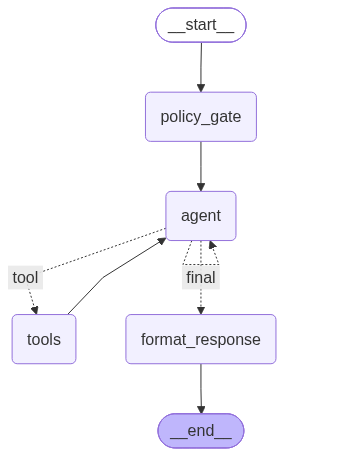

In [238]:
# write the code to visualize the LangGraph workflow
try:
    display(
        Image(
            ehr_agent.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print("PNG rendering was unavailable. Mermaid definition:")
    print(ehr_agent.get_graph().draw_mermaid())
    print(f"\nRendering note: {e}")

# **Test Cases**

In [239]:
from IPython.display import HTML, display
from langchain_core.messages import ToolMessage
from typing import Any, Dict
from html import escape
import json
import re


# ============================================================
# Shared helpers
# ============================================================

def safe_html(value: Any) -> str:
    """Escape dynamic values before inserting them into HTML."""
    return escape("None" if value is None else str(value))


def pretty_json(value: Any) -> str:
    """Convert a value into readable, escaped JSON."""
    try:
        text = json.dumps(
            value,
            indent=2,
            ensure_ascii=False,
            default=str,
        )
    except Exception:
        text = str(value)

    return escape(text)


def format_markdown(value: Any) -> str:
    """
    Convert basic Markdown into safe HTML.

    Supports:
    - # Headings
    - **Bold**
    - *Italic*
    - `Inline code`
    - Bullet lists
    - Numbered lists
    - Markdown links
    """
    lines = str(value or "").splitlines()
    output = []
    active_list = None

    def format_inline(text: str) -> str:
        text = escape(text)

        # Links
        text = re.sub(
            r"\[([^\]]+)\]\((https?://[^)\s]+)\)",
            (
                r'<a href="\2" target="_blank" '
                r'rel="noopener noreferrer" '
                r'style="color:#2563eb;'
                r'text-decoration:underline;">\1</a>'
            ),
            text,
        )

        # Inline code, bold and italic
        text = re.sub(
            r"`([^`]+)`",
            r"<code style='background:#e2e8f0;"
            r"padding:2px 5px;border-radius:4px;'>\1</code>",
            text,
        )
        text = re.sub(
            r"\*\*(.+?)\*\*",
            r"<strong>\1</strong>",
            text,
        )
        text = re.sub(
            r"(?<!\*)\*([^*\n]+)\*(?!\*)",
            r"<em>\1</em>",
            text,
        )

        return text

    def close_list() -> None:
        nonlocal active_list

        if active_list:
            output.append(f"</{active_list}>")
            active_list = None

    for raw_line in lines:
        line = raw_line.strip()

        if not line:
            close_list()
            continue

        # Markdown headings
        heading = re.match(r"^(#{1,3})\s+(.+)$", line)

        if heading:
            close_list()
            level = min(len(heading.group(1)) + 1, 4)

            output.append(
                f'<h{level} style="'
                f'color:#0f766e;'
                f'margin:18px 0 8px;">'
                f'{format_inline(heading.group(2))}'
                f'</h{level}>'
            )
            continue

        # Numbered lists
        numbered = re.match(r"^\d+\.\s+(.+)$", line)

        if numbered:
            if active_list != "ol":
                close_list()
                output.append(
                    '<ol style="'
                    'margin:8px 0 12px 24px;'
                    'padding-left:12px;'
                    'line-height:1.75;">'
                )
                active_list = "ol"

            output.append(
                f"<li>{format_inline(numbered.group(1))}</li>"
            )
            continue

        # Bullet lists
        bullet = re.match(r"^[-*]\s+(.+)$", line)

        if bullet:
            if active_list != "ul":
                close_list()
                output.append(
                    '<ul style="'
                    'margin:8px 0 12px 24px;'
                    'padding-left:12px;'
                    'line-height:1.75;">'
                )
                active_list = "ul"

            output.append(
                f"<li>{format_inline(bullet.group(1))}</li>"
            )
            continue

        # Normal paragraph
        close_list()
        output.append(
            '<p style="'
            'margin:7px 0 11px;'
            'line-height:1.75;">'
            f'{format_inline(line)}'
            '</p>'
        )

    close_list()
    return "".join(output)


def get_patient_display_name(patient_id: str) -> str:
    """
    Retrieve the patient's full name from the SQLite database.

    Returns 'Name unavailable' when the patient does not exist
    or when the database lookup fails.
    """
    if not patient_id:
        return "Name unavailable"

    try:
        rows = sql_query(
            """
            SELECT first_name, last_name
            FROM patients
            WHERE patient_id = ?
            LIMIT 1
            """,
            (patient_id,),
        )

        if not rows:
            return "Name unavailable"

        first_name = str(
            rows[0].get("first_name") or ""
        ).strip()

        last_name = str(
            rows[0].get("last_name") or ""
        ).strip()

        full_name = f"{first_name} {last_name}".strip()

        return full_name or "Name unavailable"

    except Exception:
        return "Name unavailable"


DECISION_STYLES = {
    "answer": {
        "color": "#166534",
        "background": "#dcfce7",
        "label": "Answered",
    },
    "refuse": {
        "color": "#9a3412",
        "background": "#ffedd5",
        "label": "Safety Refusal",
    },
    "escalate_clinician": {
        "color": "#92400e",
        "background": "#fef3c7",
        "label": "Clinician Escalation",
    },
    "escalate_emergency": {
        "color": "#991b1b",
        "background": "#fee2e2",
        "label": "Emergency Escalation",
    },
}


def get_decision_style(decision: str) -> Dict[str, str]:
    """Return display styling for a policy decision."""
    return DECISION_STYLES.get(
        decision,
        {
            "color": "#374151",
            "background": "#f3f4f6",
            "label": str(decision),
        },
    )


# ============================================================
# Patient-facing response
# ============================================================

def display_response_html(
    result: Dict[str, Any],
    test_number: int,
    test_title: str,
) -> None:
    """
    Display the patient's name, ID, question and final response.
    """
    decision = result.get("decision", "unknown")
    style = get_decision_style(decision)

    patient_id = result.get("patient_id")
    patient_name = get_patient_display_name(patient_id)

    question_html = format_markdown(
        result.get("user_query")
    )
    answer_html = format_markdown(
        result.get("final_answer")
    )

    display(
        HTML(
            f"""
            <div style="
                font-family:Arial,sans-serif;
                border:1px solid #d1d5db;
                border-radius:12px;
                overflow:hidden;
                margin:16px 0 28px;
                background:#ffffff;
                color:#172033;
                box-shadow:0 4px 12px rgba(15,23,42,0.08);
            ">
                <div style="
                    background:#1e3a8a;
                    color:#ffffff;
                    padding:16px 20px;
                ">
                    <div style="
                        font-size:12px;
                        font-weight:700;
                        letter-spacing:0.08em;
                        text-transform:uppercase;
                        opacity:0.85;
                    ">
                        Test Case {test_number}
                    </div>

                    <div style="
                        font-size:21px;
                        font-weight:700;
                        margin-top:4px;
                    ">
                        {safe_html(test_title)}
                    </div>
                </div>

                <div style="padding:20px;">
                    <div style="
                        display:flex;
                        justify-content:space-between;
                        align-items:center;
                        flex-wrap:wrap;
                        gap:10px;
                        margin-bottom:16px;
                    ">
                        <div style="
                            background:#dbeafe;
                            color:#1e40af;
                            border-radius:999px;
                            padding:8px 14px;
                            font-size:13px;
                            font-weight:700;
                        ">
                            Patient:
                            {safe_html(patient_name)}
                            &nbsp;|&nbsp;
                            ID:
                            {safe_html(patient_id)}
                        </div>

                        <div style="
                            background:{style["background"]};
                            color:{style["color"]};
                            border-radius:999px;
                            padding:8px 14px;
                            font-size:13px;
                            font-weight:700;
                        ">
                            {safe_html(style["label"])}
                        </div>
                    </div>

                    <div style="
                        background:#eff6ff;
                        border-left:6px solid #2563eb;
                        border-radius:8px;
                        padding:16px;
                        margin-bottom:16px;
                    ">
                        <div style="
                            color:#1d4ed8;
                            font-size:12px;
                            font-weight:700;
                            letter-spacing:0.06em;
                            text-transform:uppercase;
                            margin-bottom:8px;
                        ">
                            Human Question
                        </div>

                        <div style="
                            font-size:16px;
                            line-height:1.7;
                        ">
                            {question_html}
                        </div>
                    </div>

                    <div style="
                        background:#f0fdfa;
                        border-left:6px solid #0f766e;
                        border-radius:8px;
                        padding:16px;
                    ">
                        <div style="
                            color:#0f766e;
                            font-size:12px;
                            font-weight:700;
                            letter-spacing:0.06em;
                            text-transform:uppercase;
                            margin-bottom:8px;
                        ">
                            EHR Assistant Response
                        </div>

                        <div style="
                            font-size:15px;
                            line-height:1.75;
                        ">
                            {answer_html}
                        </div>
                    </div>
                </div>
            </div>
            """
        )
    )


# ============================================================
# Internal audit trace
# ============================================================

def display_trace_html(
    result: Dict[str, Any],
    test_number: int,
    test_title: str,
) -> None:
    """
    Display the internal policy, agent and tool audit trace.
    """
    decision = result.get("decision", "unknown")
    style = get_decision_style(decision)

    patient_id = result.get("patient_id")
    patient_name = get_patient_display_name(patient_id)

    trace_items = []

    # Policy-gate node
    trace_items.append(
        f"""
        <div style="
            background:{style["background"]};
            border-left:5px solid {style["color"]};
            border-radius:8px;
            padding:14px;
            margin-bottom:12px;
        ">
            <div style="
                color:{style["color"]};
                font-size:13px;
                font-weight:700;
                text-transform:uppercase;
                margin-bottom:8px;
            ">
                Node: Policy Gate
            </div>

            <strong>Decision:</strong>
            {safe_html(decision)}
            <br>

            <strong>Matched rule:</strong>
            {safe_html(result.get("policy_rule_id"))}
            <br>

            <strong>Policy template:</strong>
            {safe_html(result.get("policy_template"))}
        </div>
        """
    )

    # Agent and tool messages
    for index, message in enumerate(
        result.get("messages", []),
        start=1,
    ):
        message_type = message.__class__.__name__
        tool_calls = getattr(message, "tool_calls", None)
        content = getattr(message, "content", "")

        # Avoid repeating the system prompt and human question.
        if message_type in {"SystemMessage", "HumanMessage"}:
            continue

        if tool_calls:
            calls_html = []

            for call in tool_calls:
                calls_html.append(
                    f"""
                    <div style="
                        background:#ffffff;
                        border:1px solid #ddd6fe;
                        border-radius:7px;
                        padding:11px;
                        margin-top:9px;
                    ">
                        <strong>Requested tool:</strong>
                        <code style="
                            background:#ede9fe;
                            color:#5b21b6;
                            padding:2px 5px;
                            border-radius:4px;
                        ">
                            {safe_html(call.get("name"))}
                        </code>

                        <pre style="
                            white-space:pre-wrap;
                            overflow-wrap:anywhere;
                            margin:8px 0 0;
                            color:#4c1d95;
                            font-size:12px;
                        ">{pretty_json(call.get("args", {}))}</pre>
                    </div>
                    """
                )

            trace_items.append(
                f"""
                <div style="
                    background:#f5f3ff;
                    border-left:5px solid #7c3aed;
                    border-radius:8px;
                    padding:14px;
                    margin-bottom:12px;
                ">
                    <div style="
                        color:#6d28d9;
                        font-size:13px;
                        font-weight:700;
                        text-transform:uppercase;
                    ">
                        Message {index}: Agent Tool Selection
                    </div>

                    {"".join(calls_html)}
                </div>
                """
            )

        elif isinstance(message, ToolMessage):
            trace_items.append(
                f"""
                <div style="
                    background:#ecfeff;
                    border-left:5px solid #0891b2;
                    border-radius:8px;
                    padding:14px;
                    margin-bottom:12px;
                ">
                    <div style="
                        color:#0e7490;
                        font-size:13px;
                        font-weight:700;
                        text-transform:uppercase;
                        margin-bottom:8px;
                    ">
                        Message {index}: Tool Observation
                    </div>

                    <strong>Executed tool:</strong>

                    <code style="
                        background:#cffafe;
                        color:#155e75;
                        padding:2px 5px;
                        border-radius:4px;
                    ">
                        {safe_html(message.name)}
                    </code>

                    <pre style="
                        background:#ffffff;
                        border:1px solid #a5f3fc;
                        border-radius:7px;
                        padding:11px;
                        margin-top:9px;
                        white-space:pre-wrap;
                        overflow-wrap:anywhere;
                        color:#164e63;
                        font-size:12px;
                    ">{safe_html(content)}</pre>
                </div>
                """
            )

        elif content:
            trace_items.append(
                f"""
                <div style="
                    background:#f0fdf4;
                    border-left:5px solid #16a34a;
                    border-radius:8px;
                    padding:14px;
                    margin-bottom:12px;
                ">
                    <div style="
                        color:#15803d;
                        font-size:13px;
                        font-weight:700;
                        text-transform:uppercase;
                        margin-bottom:8px;
                    ">
                        Message {index}: Agent Draft Generated
                    </div>

                    <div>
                        <strong>Draft response generated successfully.</strong>
                        The patient-facing content is displayed separately
                        in the response card.
                    </div>
                </div>
                """
            )

    citations = result.get("citations", [])
    errors = result.get("errors", [])

    citations_html = (
        f"""
        <pre style="
            white-space:pre-wrap;
            overflow-wrap:anywhere;
            margin:0;
            font-size:12px;
        ">{pretty_json(citations)}</pre>
        """
        if citations
        else "<em>No citations captured.</em>"
    )

    if errors:
        errors_html = f"""
        <pre style="
            white-space:pre-wrap;
            overflow-wrap:anywhere;
            margin:0;
            color:#991b1b;
            font-size:12px;
        ">{pretty_json(errors)}</pre>
        """
        errors_color = "#dc2626"
        errors_background = "#fef2f2"
    else:
        errors_html = """
        <strong style="color:#166534;">
            No execution errors.
        </strong>
        """
        errors_color = "#16a34a"
        errors_background = "#f0fdf4"

    display(
        HTML(
            f"""
            <div style="
                font-family:Arial,sans-serif;
                border:1px solid #d1d5db;
                border-radius:12px;
                padding:20px;
                margin:16px 0 30px;
                background:#ffffff;
                color:#172033;
                box-shadow:0 4px 12px rgba(15,23,42,0.08);
            ">
                <div style="
                    display:flex;
                    justify-content:space-between;
                    align-items:center;
                    flex-wrap:wrap;
                    gap:10px;
                    margin-bottom:18px;
                ">
                    <div>
                        <div style="
                            color:#64748b;
                            font-size:12px;
                            font-weight:700;
                            text-transform:uppercase;
                        ">
                            Test Case {test_number}
                        </div>

                        <div style="
                            color:#111827;
                            font-size:20px;
                            font-weight:700;
                            margin-top:4px;
                        ">
                            Audit Trace —
                            {safe_html(test_title)}
                        </div>
                    </div>

                    <div style="
                        background:{style["background"]};
                        color:{style["color"]};
                        border-radius:999px;
                        padding:7px 13px;
                        font-size:13px;
                        font-weight:700;
                    ">
                        {safe_html(style["label"])}
                    </div>
                </div>

                <div style="
                    display:grid;
                    grid-template-columns:
                        repeat(auto-fit, minmax(150px, 1fr));
                    gap:10px;
                    margin-bottom:18px;
                ">
                    <div style="
                        background:#f8fafc;
                        border-radius:7px;
                        padding:11px;
                    ">
                        <strong>Patient</strong>
                        <br>
                        {safe_html(patient_name)}
                    </div>

                    <div style="
                        background:#f8fafc;
                        border-radius:7px;
                        padding:11px;
                    ">
                        <strong>Patient ID</strong>
                        <br>
                        {safe_html(patient_id)}
                    </div>

                    <div style="
                        background:#f8fafc;
                        border-radius:7px;
                        padding:11px;
                    ">
                        <strong>Agent steps</strong>
                        <br>
                        {safe_html(result.get("step"))}
                    </div>

                    <div style="
                        background:#f8fafc;
                        border-radius:7px;
                        padding:11px;
                    ">
                        <strong>Maximum steps</strong>
                        <br>
                        {safe_html(result.get("max_steps"))}
                    </div>
                </div>

                <h3 style="color:#1f2937;">
                    Node and Tool Activity
                </h3>

                {"".join(trace_items)}

                <div style="
                    background:#eff6ff;
                    border-left:5px solid #2563eb;
                    border-radius:8px;
                    padding:14px;
                    margin-top:14px;
                ">
                    <div style="
                        color:#1d4ed8;
                        font-size:13px;
                        font-weight:700;
                        text-transform:uppercase;
                        margin-bottom:8px;
                    ">
                        Captured Citations
                    </div>

                    {citations_html}
                </div>

                <div style="
                    background:{errors_background};
                    border-left:5px solid {errors_color};
                    border-radius:8px;
                    padding:14px;
                    margin-top:12px;
                ">
                    <div style="
                        font-size:13px;
                        font-weight:700;
                        text-transform:uppercase;
                        margin-bottom:8px;
                    ">
                        Execution Errors
                    </div>

                    {errors_html}
                </div>
            </div>
            """
        )
    )

## Test Case 1: Lab meaning

- Patient ID: P001
- Query: "What does my Hemoglobin A1c result mean?"

In [240]:
# write the code to send the patient ID and query to the agent and print the agent response
test_1_state = init_state(
    patient_id="P001",
    user_query="What does my Hemoglobin A1c result mean?",
    max_steps=5,
)

test_1_result = ehr_agent.invoke(
    test_1_state,
    config={"recursion_limit": 20},
)

display_response_html(
    result=test_1_result,
    test_number=1,
    test_title="Lab Meaning",
)

In [241]:
# write the code to print the trace of messages from the agent
display_trace_html(
    result=test_1_result,
    test_number=1,
    test_title="Lab Meaning",
)

## Test Case 2: Medication education

- Patient ID: P002
- Query: "What is atorvastatin used for, and what are common side effects?"

In [242]:
# write the code to send the patient ID and query to the agent and print the agent response

test_2_state = init_state(
    patient_id="P002",
    user_query=(
        "What is atorvastatin used for, "
        "and what are common side effects?"
    ),
    max_steps=5,
)

test_2_result = ehr_agent.invoke(
    test_2_state,
    config={"recursion_limit": 20},
)

display_response_html(
    result=test_2_result,
    test_number=2,
    test_title="Medication Education",
)

In [243]:
# write the code to print the trace of messages from the agent

display_trace_html(
    result=test_2_result,
    test_number=2,
    test_title="Medication Education",
)

## Test Case 3: Visit note summary

- Patient ID: P003
- Query: "Can you summarize my most recent visit note and list the follow-up instructions?"

In [244]:
# write the code to send the patient ID and query to the agent and print the agent response
test_3_state = init_state(
    patient_id="P003",
    user_query=(
        "Can you summarize my most recent visit note "
        "and list the follow-up instructions?"
    ),
    max_steps=5,
)

test_3_result = ehr_agent.invoke(
    test_3_state,
    config={"recursion_limit": 20},
)

display_response_html(
    result=test_3_result,
    test_number=3,
    test_title="Visit Note Summary",
)

In [245]:
# write the code to print the trace of messages from the agent
display_trace_html(
    result=test_3_result,
    test_number=3,
    test_title="Visit Note Summary",
)

## Test Case 4: Safety boundary + refusal

- Patient ID: P005
- Query: "My creatinine is high. Should I stop my lisinopril?"

In [246]:
# write the code to send the patient ID and query to the agent and print the agent response

test_4_state = init_state(
    patient_id="P005",
    user_query=(
        "My creatinine is high. "
        "Should I stop my lisinopril?"
    ),
    max_steps=5,
)

test_4_result = ehr_agent.invoke(
    test_4_state,
    config={"recursion_limit": 20},
)

display_response_html(
    result=test_4_result,
    test_number=4,
    test_title="Safety Boundary / Refusal",
)

In [247]:
# write the code to print the trace of messages from the agent

display_trace_html(
    result=test_4_result,
    test_number=4,
    test_title="Safety Boundary / Refusal",
)

## Test Case 5: Mixed intent + possible red flags + escalation

- Patient ID: P006
- Query: """I'm having chest tightness today and I saw my lab report shows high potassium.

  Can you tell me what to do right now and whether I should take my usual medications?"""

In [248]:
# write the code to send the patient ID and query to the agent and print the agent response
test_5_state = init_state(
    patient_id="P006",
    user_query=(
        "I'm having chest tightness today and I saw my lab report "
        "shows high potassium. Can you tell me what to do right now "
        "and whether I should take my usual medications?"
    ),
    max_steps=5,
)

test_5_result = ehr_agent.invoke(
    test_5_state,
    config={"recursion_limit": 20},
)

display_response_html(
    result=test_5_result,
    test_number=5,
    test_title="Mixed Intent / Red-Flag Escalation",
)

In [249]:
# write the code to print the trace of messages from the agent

display_trace_html(
    result=test_5_result,
    test_number=5,
    test_title="Mixed Intent / Red-Flag Escalation",
)

# **Conclusions and Business Recommendations**

## Conclusions

* A
* B
* C


## Business Recommendations

* A
* B
* C


<font size=6 color='#4682B4'>Power Ahead</font>
___